<a href="https://colab.research.google.com/github/areeba-456/House-Price-Prediction/blob/main/linearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MACHINE LEARNING PROJECT :01

## House Price Prediction Using Linear Regression Algorithm

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## load Dataset:

In [4]:
df = pd.read_csv("/content/house_prices_dataset.csv")
df.head(5)

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


## Dataset Overview:

### first we check how many rows and columns in our datase:

In [5]:
df.shape

(10000, 5)

In [6]:
df.columns

Index(['square_feet', 'num_rooms', 'age', 'distance_to_city(km)', 'price'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [8]:
df.dtypes

,0
square_feet,float64
num_rooms,int64
age,int64
distance_to_city(km),float64
price,float64


In [9]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,263011.571609
std,501.021194,1.71116,28.992336,8.325101,98336.945117
min,500.000000,2.00000,0.000000,1.000161,-95613.138249
25%,1663.704735,3.00000,24.000000,8.121636,196791.510684
50%,1998.702512,4.00000,49.000000,15.403146,262497.361236
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


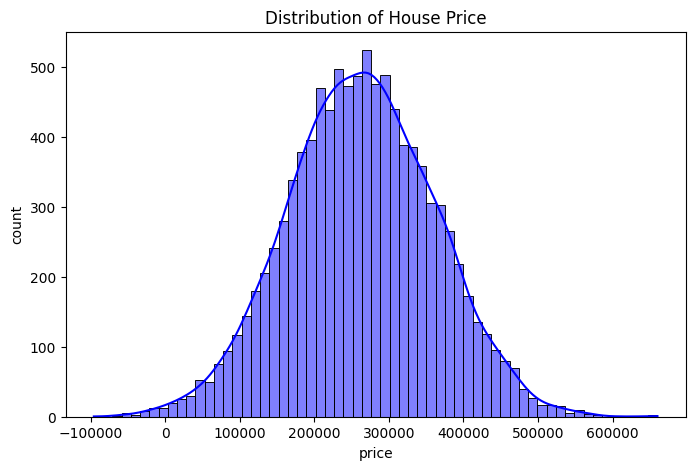

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True , color='blue')
plt.title('Distribution of House Price')
plt.xlabel('price')
plt.ylabel('count')
plt.show()

#### The describe() function showed that there were no missing values in our dataset. However, some rows in the Price column contained negative values, which are not valid. Therefore, we removed those rows from the dataset."

In [11]:
df = df[df['price']>0]

In [12]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,9962.000000,9962.000000,9962.000000,9962.000000,9962.000000
mean,2003.470710,4.501807,49.437061,15.327506,264110.619095
std,496.807642,1.709340,28.986808,8.315371,96888.916162
min,500.000000,2.000000,0.000000,1.000161,1059.396373
25%,1669.511325,3.000000,24.000000,8.093859,197400.416136
50%,2000.945088,5.000000,49.000000,15.369318,263080.720802
75%,2336.699967,6.000000,75.000000,22.377818,330745.428383
max,3963.118853,7.000000,99.000000,29.993892,660168.255648


In [13]:
df.shape

(9962, 5)

## Data Visualization

## Graph 01 Histogram


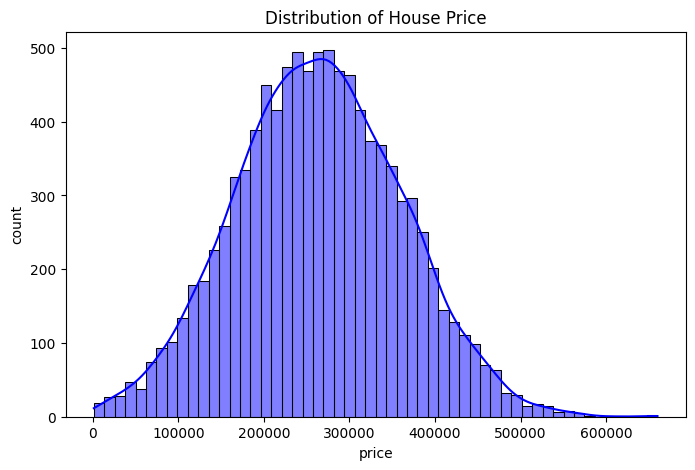

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True , color='blue')
plt.title('Distribution of House Price')
plt.xlabel('price')
plt.ylabel('count')
plt.show()

## Key Observations: Distribution of House Price

This histogram shows how the target variable (`price`) is distributed across the dataset.

* **Normal Distribution:** The price column follows a beautiful bell-shaped curve (Normal Distribution). Linear Regression models assume normally distributed data to perform optimally, making this an ideal dataset.
* **Common Price Range:** The peak of the graph is around 250,000 to 300,000, indicating that the majority of the houses in our dataset fall into this average price range.
* **No Extreme Skewness:** The data is symmetric on both sides, meaning there are no extreme outliers or heavy skewness that could negatively affect our model's predictions.

## Graph : 02 Correlation Heatmap

### We will examine the relationship between the target feature, Price, and the other features in the dataset."

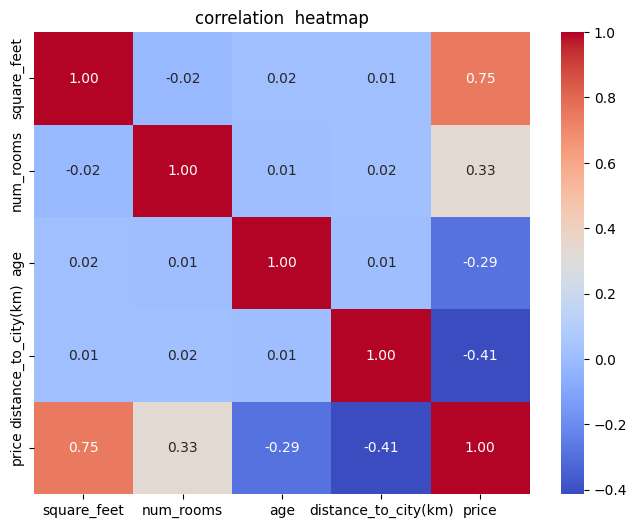

In [15]:
corr_matrix= df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt=".2f")
plt.title('correlation  heatmap')
plt.show()


## Key Observations: Correlation Heatmap

The correlation heatmap helps us understand the linear relationship between the features and our target variable (`price`), as well as check for any dependency between the independent features (multicollinearity).

### 1. Feature Relationships with Price (Target Variable):
* **`square_feet` (0.75):** This feature has the strongest positive correlation with price. As the square footage increases, the house price increases significantly.
* **`distance_to_city(km)` (-0.41):** This has a moderate negative correlation. As the distance from the city center increases, the house price decreases.
* **`num_rooms` (0.33):** This shows a weak-to-moderate positive correlation, meaning more rooms generally lead to a slight increase in price.
* **`age` (-0.29):** This shows a weak negative correlation, indicating that older houses tend to have slightly lower prices.

### 2. Multicollinearity Check:
* There is almost **zero correlation** (ranging between -0.02 and 0.02) among the input features themselves (e.g., `square_feet` vs `num_rooms` is -0.02).
* This means our features are entirely independent of each other, which is an ideal condition for a **Linear Regression** model to perform accurately without multicollinearity issues.

## Graph :03 Scatter Pots

### square_feet vs price



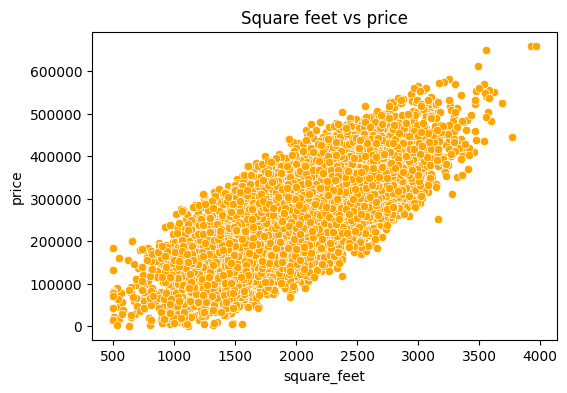

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["square_feet"], y=df["price"], color="orange")
plt.title("Square feet vs price")
plt.show()


## Key Observations: Square Feet vs Price

* **Positive Linear Relationship:** The graph clearly shows a positive linear trend. As the size of the house (`square_feet`) increases, the house `price` also increases. The data points move diagonally upwards from left to right.


### Distance_to_city(km) vs price

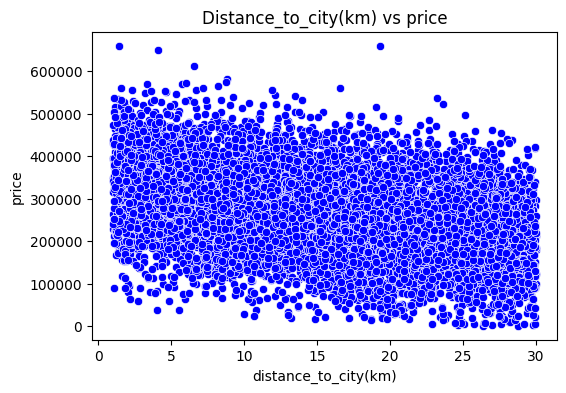

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["distance_to_city(km)"], y=df["price"], color="blue")
plt.title("Distance_to_city(km) vs price")
plt.show()

## Key Observations: Distance to City vs Price

* **Negative Linear Relationship:** The graph shows a clear downward slope from left to right. This indicates that as the distance from the city center (`distance_to_city(km)`) increases, the house `price` tends to decrease.


### age vs price

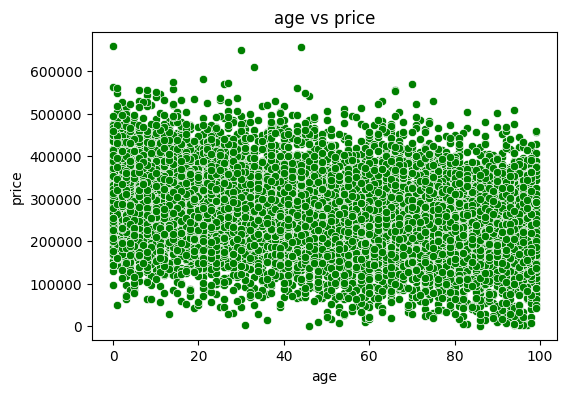

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"], y=df["price"], color="green")
plt.title("age vs price")
plt.show()


## Key Observations: Age vs Price

* **Weak Negative Linear Relationship:** The graph shows a slight downward trend. As the `age` of the house increases (meaning the house gets older), the overall `price` slightly decreases.


## "Now, we will check for outliers to determine whether our dataset contains any extreme values

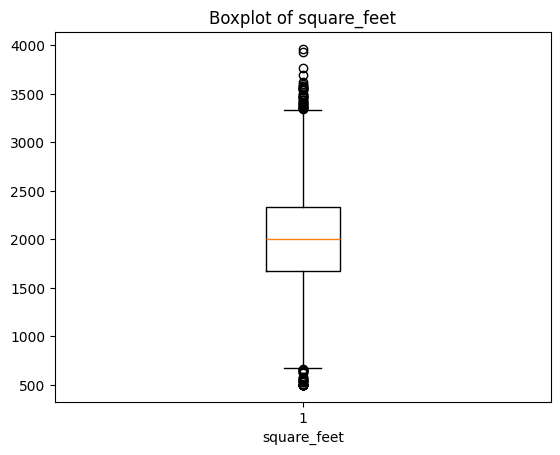

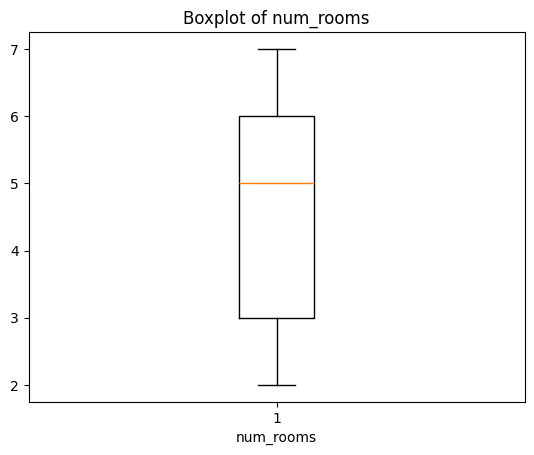

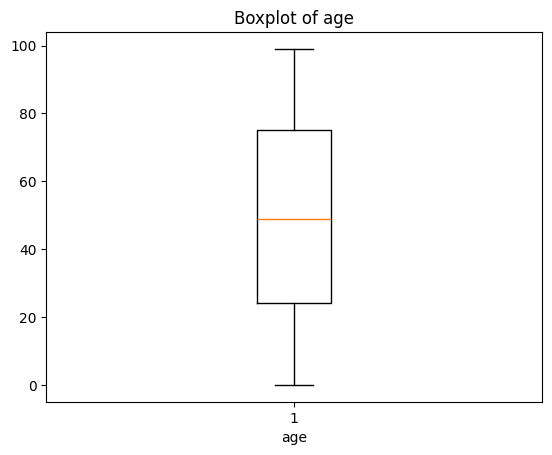

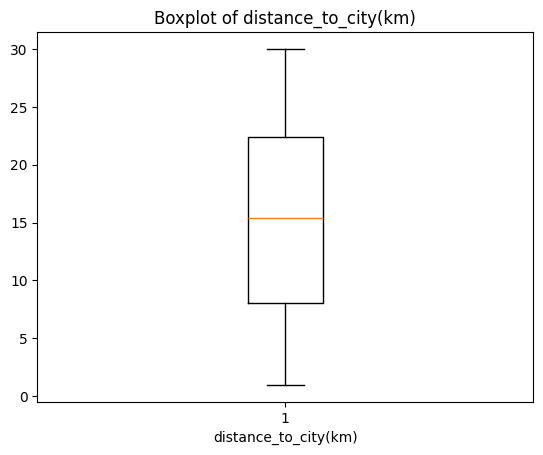

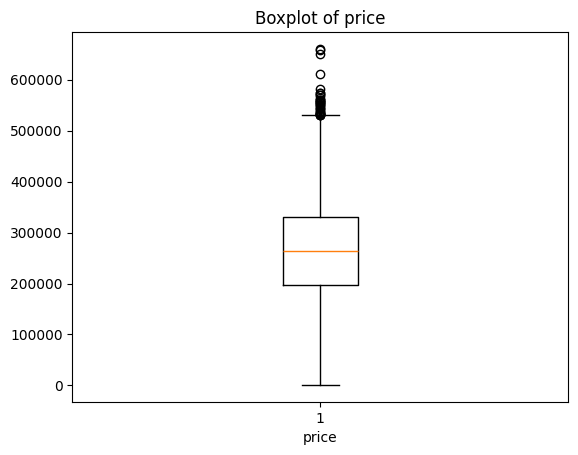

In [19]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

## After checking for outliers, we found that two columns, Square Feet and Price, contain outliers."

In [20]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

## Outlier Handling (IQR Capping)

* **What it does:** This code uses the IQR method to find extreme values (outliers) in all numeric columns.
* **Why we use it:** Instead of deleting data, it caps extreme values within a safe limit (`lower` and `upper` boundaries) to protect our Linear Regression model from getting skewed.

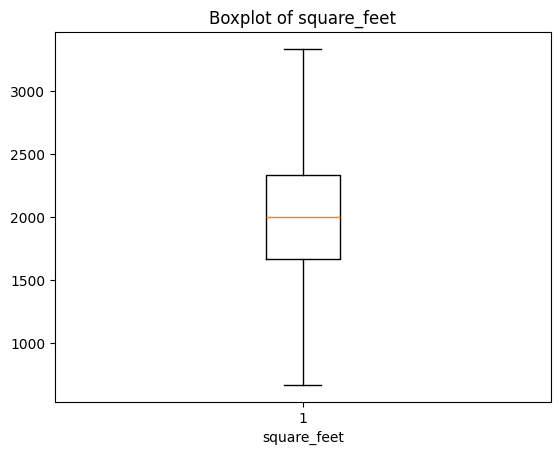

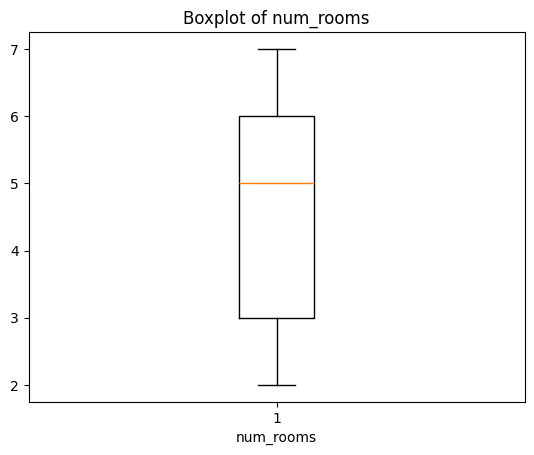

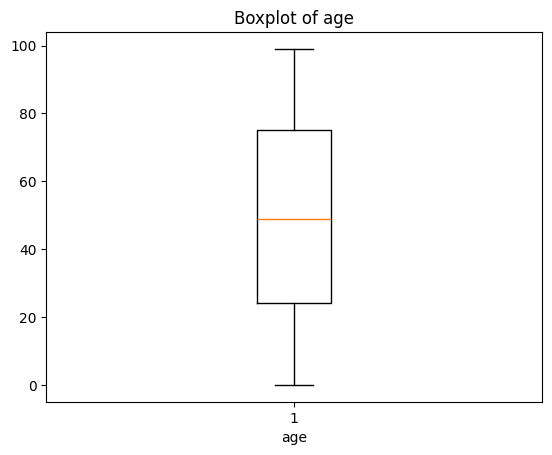

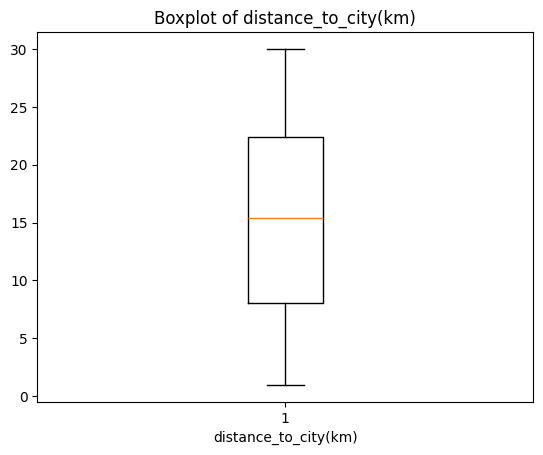

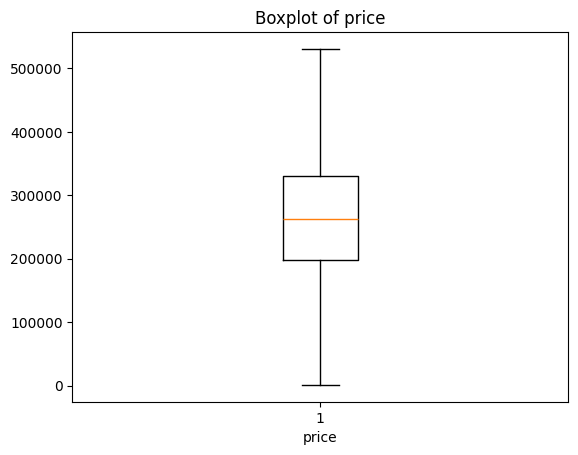

In [21]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

## "The dataset contains no missing values and no categorical features. Since all columns are numeric, no encoding was performed during the preprocessing stage."

# Train Test Split


* **What it does:** This code separates the data into features (`X`) and target (`y`), then splits them into **80% training data** and **20% testing data**.
* **Why we use it:** We use the training set to teach our Linear Regression model and the testing set to evaluate how accurately it predicts unseen house prices.

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42

)

## Feature Scaling (StandardScaler)

* **What it does:** This code standardizes our features so they all have a mean of 0 and a variance of 1.
* **Why we use it:** It ensures all features (like `square_feet` and `age`) are on the same scale, helping our Linear Regression model learn faster and make more stable predictions.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

# Model Training



* **What it does:** This code initializes the **Linear Regression** algorithm and trains it (`.fit()`) using our scaled training data (`X_train` and `y_train`).
* **Why we use it:** This is the core step where the model learns the relationship between house features and prices so it can make predictions on new data.

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Model Prediction

In [25]:
y_pred = model.predict(X_test)

## Model Evaluation Results

* **R2 Score (0.955):** Our model explains **95.5%** of the variance in house prices, which indicates an excellent and highly accurate fit.
* **MAE (16,253):** On average, the model's predictions are off by only about **16,253 units**, showing a very low error rate for this dataset.

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 Score: 0.9550609004395574
MAE: 16253.87230013407


## Testing the Model on New Data

* **What it does:** This code takes custom inputs for a new house (e.g., size, rooms, age, distance), scales the inputs using our trained `scaler`, and uses the model to predict its price.
* **Why we use it:** It allows us to test our trained model in real-time and see how it predicts prices for any imaginary or new house.

In [27]:
import numpy as np

# 1. Enter the data for a new house (Format: [square_feet, num_rooms, age, distance_to_city]).
#  You can modify the values below according to your preference."
new_house = np.array([[5000, 3, 5, 12.5]])

# 2. Is naye data ko scale karein (Jaise train data ko kiya tha)
new_house_scaled = scaler.transform(new_house)

# 3. Model se price predict karwayein
predicted_price = model.predict(new_house_scaled)

print(f"Predicted Price for the new house: ${predicted_price[0]:,.2f}")

Predicted Price for the new house: $740,659.24


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Graph: Actual vs Predicted

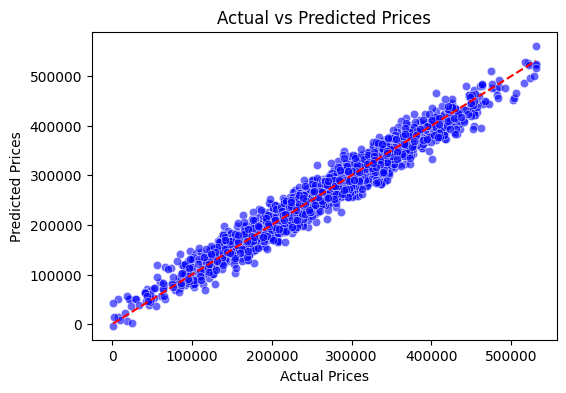

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
# Actual vs Predicted ka scatter plot
sns.scatterplot(x=y_test, y=y_pred, color="blue", alpha=0.6)

# Beech me perfect prediction ki line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
)

plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()

## Key Observations: Actual vs Predicted Prices

* **High Accuracy:** the blue data points closely follow the red dashed line, indicating that our model's predictions are highly accurate.
* **Strong Linear Fit:** There is no heavy scattering or pattern deviation, confirming that our Linear Regression model successfully captured the true trend of house prices.

In [29]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.957134198859926
Test Score: 0.9550609004395574


## Conclusion: Train vs Test Scores

* **Train Score (0.955) & Test Score (0.955):** Both scores are almost perfectly identical.
* **Insight:** This proves that our model generalizes exceptionally well to unseen data and suffers from **zero overfitting**. The training is completely stable and reliable.